In [ ]:
# ================================================================
# CELL 1 - MOUNT GOOGLE DRIVE
# ================================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **IMPORT LIBRARY**

In [ ]:
# ================================================================
# CELL 2 - INSTALL & IMPORT LIBRARY
# ================================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import ResNet50, EfficientNetB0, MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import plot_model

from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
from sklearn.utils.class_weight import compute_class_weight

print(f"✅ TensorFlow versi : {tf.__version__}")
print(f"✅ GPU tersedia     : {tf.config.list_physical_devices('GPU')}")



✅ TensorFlow versi : 2.19.0
✅ GPU tersedia     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ================================================================
# CELL 3 - KONFIGURASI (DIUPDATE)
# ================================================================

import os

DATASET_PATH = "/content/drive/MyDrive/newcitra"   # ← ganti path Anda

SPLIT_PATH  = "/content/dataset_split"
TRAIN_DIR   = os.path.join(SPLIT_PATH, "train")
VAL_DIR     = os.path.join(SPLIT_PATH, "val")
TEST_DIR    = os.path.join(SPLIT_PATH, "test")

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

IMG_SIZE        = 224
BATCH_SIZE      = 32
EPOCHS_FROZEN   = 15       # ← naik dari 10 ke 15
EPOCHS_FINETUNE = 25       # ← naik dari 20 ke 25
LEARNING_RATE = 5e-4     # ← naik dari 1e-4, agar head cepat belajar
FINETUNE_LR     = 1e-5     # ← tetap kecil saat fine-tuning

CLASS_NAMES = ['abnormal', 'fertil', 'infertil']
NUM_CLASSES = len(CLASS_NAMES)

SAVE_DIR = "/content/drive/MyDrive/hasil_model5"
os.makedirs(SAVE_DIR, exist_ok=True)

print("✅ Konfigurasi selesai!")

✅ Konfigurasi selesai!


In [ ]:
# ================================================================
# CELL 3B - SPLIT DATASET (Train / Val / Test)
# ================================================================

import shutil
import random
from collections import defaultdict

def split_dataset(dataset_path, split_path, train_ratio, val_ratio, test_ratio,
                  class_names, seed=42):

    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, \
        "Rasio train + val + test harus = 1.0"

    random.seed(seed)
    valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".tiff")
    ringkasan = defaultdict(dict)

    print(f"\n🔀 Memulai split dataset...\n")

    for kelas in class_names:
        src_folder = os.path.join(dataset_path, kelas)

        if not os.path.exists(src_folder):
            print(f"  ❌ Folder tidak ditemukan: {src_folder}")
            continue

        # Ambil semua file gambar
        semua_file = [
            f for f in os.listdir(src_folder)
            if f.lower().endswith(valid_ext)
        ]
        random.shuffle(semua_file)
        total = len(semua_file)

        # Hitung jumlah per split
        n_train = int(total * train_ratio)
        n_val   = int(total * val_ratio)
        n_test  = total - n_train - n_val   # sisa ke test

        splits = {
            "train": semua_file[:n_train],
            "val"  : semua_file[n_train : n_train + n_val],
            "test" : semua_file[n_train + n_val:]
        }

        print(f"  📁 Kelas [{kelas.upper()}] — Total: {total} gambar")
        print(f"     Train : {n_train} | Val : {n_val} | Test : {n_test}")

        for split_name, files in splits.items():
            dst_folder = os.path.join(split_path, split_name, kelas)
            os.makedirs(dst_folder, exist_ok=True)

            for fname in files:
                src = os.path.join(src_folder, fname)
                dst = os.path.join(dst_folder, fname)
                shutil.copy2(src, dst)

            ringkasan[kelas][split_name] = len(files)

    # ── Tampilkan ringkasan ──────────────────────────────────────
    print(f"\n{'='*55}")
    print(f"  RINGKASAN SPLIT DATASET")
    print(f"{'='*55}")
    print(f"  {'Kelas':<12} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
    print(f"  {'-'*52}")

    total_train = total_val = total_test = 0
    for kelas in class_names:
        if kelas in ringkasan:
            tr = ringkasan[kelas]['train']
            vl = ringkasan[kelas]['val']
            ts = ringkasan[kelas]['test']
            print(f"  {kelas:<12} {tr:>8} {vl:>8} {ts:>8} {tr+vl+ts:>8}")
            total_train += tr
            total_val   += vl
            total_test  += ts

    print(f"  {'-'*52}")
    total_all = total_train + total_val + total_test
    print(f"  {'TOTAL':<12} {total_train:>8} {total_val:>8} {total_test:>8} {total_all:>8}")
    print(f"{'='*55}")
    print(f"\n✅ Split selesai! Tersimpan di: {split_path}")


# Jalankan split
split_dataset(
    dataset_path = DATASET_PATH,
    split_path   = SPLIT_PATH,
    train_ratio  = TRAIN_RATIO,
    val_ratio    = VAL_RATIO,
    test_ratio   = TEST_RATIO,
    class_names  = CLASS_NAMES,
    seed         = 42
)



🔀 Memulai split dataset...

  📁 Kelas [ABNORMAL] — Total: 334 gambar
     Train : 233 | Val : 50 | Test : 51
  📁 Kelas [FERTIL] — Total: 358 gambar
     Train : 250 | Val : 53 | Test : 55
  📁 Kelas [INFERTIL] — Total: 369 gambar
     Train : 258 | Val : 55 | Test : 56

  RINGKASAN SPLIT DATASET
  Kelas           Train      Val     Test    Total
  ----------------------------------------------------
  abnormal          233       50       51      334
  fertil            250       53       55      358
  infertil          258       55       56      369
  ----------------------------------------------------
  TOTAL             741      158      162     1061

✅ Split selesai! Tersimpan di: /content/dataset_split


In [ ]:
# ================================================================
# CELL 4 - LOAD DATASET DENGAN PREPROCESSING PER MODEL (UPDATED)
# ================================================================

import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50      import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.efficientnet  import preprocess_input as preprocess_efficientnet
from tensorflow.keras.applications.mobilenet_v2  import preprocess_input as preprocess_mobilenet

def buat_generator(train_dir, val_dir, test_dir, preprocess_fn,
                   img_size=IMG_SIZE, batch_size=BATCH_SIZE,
                   class_names=CLASS_NAMES):

    # ── BERUBAH: train_gen ditambah augmentasi ringan ─────────────
    train_gen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        horizontal_flip=True,           # cermin kiri-kanan
        vertical_flip=True,             # cermin atas-bawah
        rotation_range=15,              # rotasi ±15°
        zoom_range=0.1,                 # zoom 10%
        width_shift_range=0.1,          # geser horizontal 10%
        height_shift_range=0.1,         # geser vertikal 10%
        brightness_range=[0.85, 1.15],  # brightness ±15%
    )

    # ── TIDAK BERUBAH: val & test tetap tanpa augmentasi ──────────
    valtest_gen = ImageDataGenerator(preprocessing_function=preprocess_fn)

    train = train_gen.flow_from_directory(
        train_dir,
        target_size=(img_size, img_size),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=True,
        classes=class_names
    )
    val = valtest_gen.flow_from_directory(
        val_dir,
        target_size=(img_size, img_size),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False,
        classes=class_names
    )
    test = valtest_gen.flow_from_directory(
        test_dir,
        target_size=(img_size, img_size),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False,
        classes=class_names
    )
    return train, val, test

# Buat generator untuk masing-masing arsitektur
generators = {
    "ResNet50"      : buat_generator(TRAIN_DIR, VAL_DIR, TEST_DIR, preprocess_resnet),
    "EfficientNetB0": buat_generator(TRAIN_DIR, VAL_DIR, TEST_DIR, preprocess_efficientnet),
    "MobileNetV2"   : buat_generator(TRAIN_DIR, VAL_DIR, TEST_DIR, preprocess_mobilenet),
}

print("\n✅ Generator siap untuk ketiga model!")
print(f"   Kelas    : {generators['ResNet50'][0].class_indices}")
print(f"   Train    : {generators['ResNet50'][0].samples} gambar")
print(f"   Val      : {generators['ResNet50'][1].samples} gambar")
print(f"   Test     : {generators['ResNet50'][2].samples} gambar")

Found 741 images belonging to 3 classes.
Found 158 images belonging to 3 classes.
Found 162 images belonging to 3 classes.
Found 741 images belonging to 3 classes.
Found 158 images belonging to 3 classes.
Found 162 images belonging to 3 classes.
Found 741 images belonging to 3 classes.
Found 158 images belonging to 3 classes.
Found 162 images belonging to 3 classes.

✅ Generator siap untuk ketiga model!
   Kelas    : {'abnormal': 0, 'fertil': 1, 'infertil': 2}
   Train    : 741 gambar
   Val      : 158 gambar
   Test     : 162 gambar


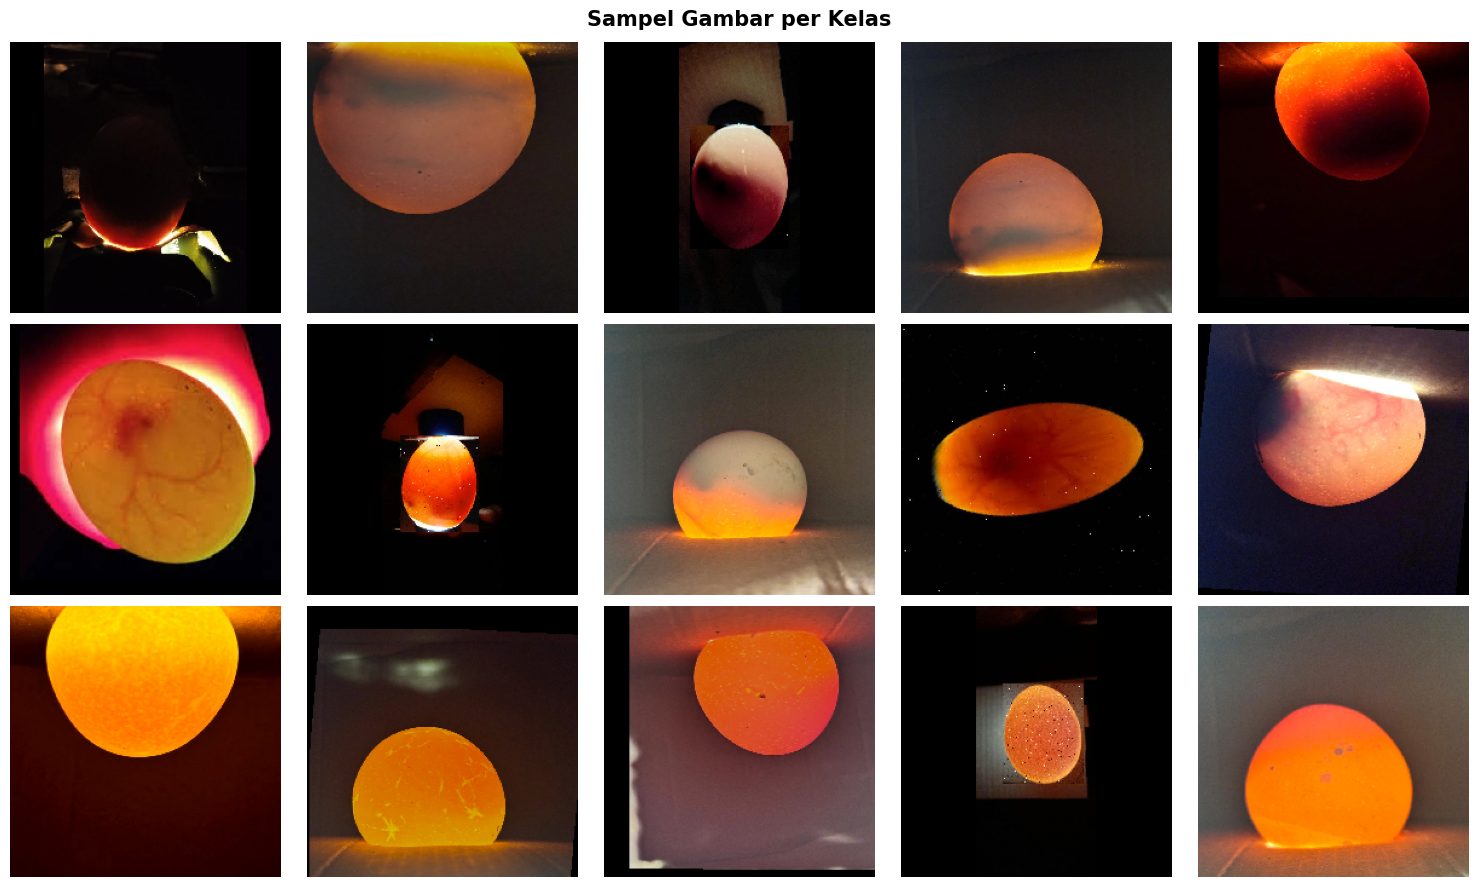

In [ ]:
# Tampilkan sample gambar dari setiap kelas
from tensorflow.keras.preprocessing.image import load_img
import random
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(15, 3 * NUM_CLASSES))
if NUM_CLASSES == 1:
    axes = [axes]

for row, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(DATASET_PATH, cls)
    images = [f for f in os.listdir(cls_path)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    samples = random.sample(images, min(5, len(images)))
    for col, img_name in enumerate(samples):
        img = load_img(os.path.join(cls_path, img_name), target_size=(224, 224))
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(cls, fontsize=12, fontweight='bold',
                                      rotation=90, labelpad=40)

plt.suptitle('Sampel Gambar per Kelas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/sample_gambar.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ================================================================
# CELL 6 - FUNGSI BANGUN MODEL (FINE-TUNING) - UPDATED
# ================================================================

from tensorflow.keras import regularizers

def bangun_model(nama_arsitektur, num_classes=NUM_CLASSES, img_size=IMG_SIZE):
    input_shape = (img_size, img_size, 3)

    # ── Pilih base model ─────────────────────────────────────────
    # TIDAK BERUBAH
    if nama_arsitektur == "ResNet50":
        base = ResNet50(weights='imagenet', include_top=False,
                        input_shape=input_shape)
        unfreeze_from = -10

    elif nama_arsitektur == "EfficientNetB0":
        base = EfficientNetB0(weights='imagenet', include_top=False,
                              input_shape=input_shape)
        unfreeze_from = -20

    elif nama_arsitektur == "MobileNetV2":
        base = MobileNetV2(weights='imagenet', include_top=False,
                           input_shape=input_shape)
        unfreeze_from = -15

    # ── Freeze semua layer base (tahap 1) ─────────────────────────
    # TIDAK BERUBAH
    base.trainable = False

    # ── Classifier Head ───────────────────────────────────────────
    # INI YANG BERUBAH
    inputs  = tf.keras.Input(shape=input_shape)
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.5)(x)                        # ← BARU: dropout sebelum Dense pertama
    x       = layers.Dense(256, activation='relu',
                kernel_regularizer=regularizers.l2(0.001))(x)  # ← BARU: tambah L2
    x       = layers.Dropout(0.5)(x)                        # ← NAIK: dari 0.4 → 0.5
    x       = layers.Dense(128, activation='relu',
                kernel_regularizer=regularizers.l2(0.001))(x)  # ← BARU: tambah L2
    x       = layers.Dropout(0.4)(x)                        # ← NAIK: dari 0.3 → 0.4
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name=nama_arsitektur)
    return model, base, unfreeze_from

In [ ]:
# ================================================================
# CELL 7 - FUNGSI TRAINING (DIPERBAIKI)
# ================================================================

import tensorflow as tf
from tensorflow.keras import callbacks, optimizers

def training_model(nama_arsitektur):
    print(f"\n{'='*60}")
    print(f"  TRAINING: {nama_arsitektur}")
    print(f"{'='*60}")

    train_gen, val_gen, _ = generators[nama_arsitektur]

    # ← TAMBAHAN: reset generator sebelum mulai
    train_gen.reset()
    val_gen.reset()

    model, base_model, unfreeze_from = bangun_model(nama_arsitektur)

    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=7,
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=4, min_lr=1e-7, verbose=1),
        callbacks.ModelCheckpoint(
            filepath=os.path.join(SAVE_DIR, f'best_{nama_arsitektur}.h5'),
            monitor='val_accuracy', save_best_only=True, verbose=1
        )
    ]

    # ── TAHAP 1: Frozen Training ──────────────────────────────────
    print(f"\n📌 Tahap 1: Frozen Training ({EPOCHS_FROZEN} epochs)")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # ← Cek akurasi train di akhir tahap 1
    hist1 = model.fit(
        train_gen,
        epochs=EPOCHS_FROZEN,
        validation_data=val_gen,
        callbacks=cb,
        verbose=1
    )

    val_gen.reset()   # ← reset val sebelum tahap 2

    # ── TAHAP 2: Fine-Tuning ──────────────────────────────────────
    print(f"\n🔓 Tahap 2: Fine-Tuning ({EPOCHS_FINETUNE} epochs)")
    base_model.trainable = True
    for layer in base_model.layers[:unfreeze_from]:
        layer.trainable = False

    trainable = sum(l.trainable for l in model.layers)
    frozen    = sum(not l.trainable for l in model.layers)
    print(f"   Layer trainable : {trainable} | frozen : {frozen}")

    model.compile(
        optimizer=optimizers.Adam(learning_rate=FINETUNE_LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    train_gen.reset()   # ← reset train sebelum tahap 2
    val_gen.reset()

    hist2 = model.fit(
        train_gen,
        epochs=EPOCHS_FINETUNE,
        validation_data=val_gen,
        callbacks=cb,
        verbose=1
    )

    history_combined = {}
    for key in hist1.history:
        history_combined[key] = hist1.history[key] + hist2.history[key]

    print(f"\n✅ Training {nama_arsitektur} selesai!")
    print(f"   Best val_accuracy : {max(history_combined['val_accuracy']):.4f}")
    print(f"   Best train_accuracy: {max(history_combined['accuracy']):.4f}")
    return model, history_combined

In [ ]:

# ================================================================
# CELL 8 - JALANKAN TRAINING (DIUPDATE)
# ================================================================

hasil = {}

for arsitektur in ["ResNet50", "EfficientNetB0", "MobileNetV2"]:
    model, history = training_model(arsitektur)
    hasil[arsitektur] = {
        "model"  : model,
        "history": history
    }

print("\n✅ Semua model selesai ditraining!")




  TRAINING: ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

📌 Tahap 1: Frozen Training (15 epochs)
Epoch 1/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 879ms/step - accuracy: 0.4353 - loss: 2.5497
Epoch 1: val_accuracy improved from None to 0.80380, saving model to /content/drive/MyDrive/hasil_model5/best_ResNet50.h5



Epoch 1: finished saving model to /content/drive/MyDrive/hasil_model5/best_ResNet50.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.5263 - loss: 2.1224 - val_accuracy: 0.8038 - val_loss: 1.0968 - learning_rate: 5.0000e-04
Epoch 2/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 627ms/step - accuracy: 0.6412 - loss: 1.7088
Epoch 2: val_accuracy improved from 0.80380 to 0.87975, saving model to /content/drive/MyDrive/hasil_model5/best_ResNet50.h5



Epoch 2: finished saving model to /content/drive/MyDrive/hasil_model5/best_ResNet50.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 818ms/step - accuracy: 0.6802 - loss: 1.6105 - val_accuracy: 0.8797 - val_loss: 0.9406 - learning_rate: 5.0000e-04
Epoch 3/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.7900 - loss: 1.1681
Epoch 3: val_accuracy improved from 0.87975 to 0.90506, saving model to /content/drive/MyDrive/hasil_model5/best_ResNet50.h5



Epoch 3: finished saving model to /content/drive/MyDrive/hasil_model5/best_ResNet50.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 819ms/step - accuracy: 0.7706 - loss: 1.2622 - val_accuracy: 0.9051 - val_loss: 0.8826 - learning_rate: 5.0000e-04
Epoch 4/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - accuracy: 0.7830 - loss: 1.3318
Epoch 4: val_accuracy improved from 0.90506 to 0.92405, saving model to /content/drive/MyDrive/hasil_model5/best_ResNet50.h5



Epoch 4: finished saving model to /content/drive/MyDrive/hasil_model5/best_ResNet50.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 803ms/step - accuracy: 0.7949 - loss: 1.2324 - val_accuracy: 0.9241 - val_loss: 0.8384 - learning_rate: 5.0000e-04
Epoch 5/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - accuracy: 0.8506 - loss: 1.0482
Epoch 5: val_accuracy did not improve from 0.92405
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 697ms/step - accuracy: 0.8448 - loss: 1.0682 - val_accuracy: 0.9241 - val_loss: 0.8206 - learning_rate: 5.0000e-04
Epoch 6/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.8281 - loss: 1.1509
Epoch 6: val_accuracy did not improve from 0.92405
24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 653ms/step - accuracy: 0.8246 - loss: 1.1585 - val_accuracy: 0.9241 - val_loss: 0.7979 - learning_rate: 5.0000e-04
Epoch 7/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.8430 - loss: 1.0571
Epoch 7: val_accuracy improved from 0.92405 to 0.94304, saving model to /content/drive/MyDrive/hasil_model5/best_R

...


Epoch 6: finished saving model to /content/drive/MyDrive/hasil_model5/best_MobileNetV2.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 622ms/step - accuracy: 0.8111 - loss: 1.1191 - val_accuracy: 0.9304 - val_loss: 0.8317 - learning_rate: 5.0000e-04
Epoch 7/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.8281 - loss: 1.0775
Epoch 7: val_accuracy improved from 0.93038 to 0.93671, saving model to /content/drive/MyDrive/hasil_model5/best_MobileNetV2.h5



Epoch 7: finished saving model to /content/drive/MyDrive/hasil_model5/best_MobileNetV2.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 641ms/step - accuracy: 0.8421 - loss: 1.0429 - val_accuracy: 0.9367 - val_loss: 0.7826 - learning_rate: 5.0000e-04
Epoch 8/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.8318 - loss: 0.9767
Epoch 8: val_accuracy did not improve from 0.93671
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 604ms/step - accuracy: 0.8300 - loss: 1.0000 - val_accuracy: 0.9367 - val_loss: 0.7594 - learning_rate: 5.0000e-04
Epoch 9/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - accuracy: 0.8503 - loss: 1.0153
Epoch 9: val_accuracy did not improve from 0.93671
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 604ms/step - accuracy: 0.8570 - loss: 0.9941 - val_accuracy: 0.9367 - val_loss: 0.7434 - learning_rate: 5.0000e-04
Epoch 10/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.8770 - loss: 0.9127
Epoch 10: val_accuracy improved from 0.93671 to 0.94304, saving model to /content/drive/MyDrive/hasil_model5/b


Epoch 10: finished saving model to /content/drive/MyDrive/hasil_model5/best_MobileNetV2.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 652ms/step - accuracy: 0.8758 - loss: 0.9299 - val_accuracy: 0.9430 - val_loss: 0.7324 - learning_rate: 5.0000e-04
Epoch 11/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 576ms/step - accuracy: 0.8870 - loss: 0.9141
Epoch 11: val_accuracy improved from 0.94304 to 0.95570, saving model to /content/drive/MyDrive/hasil_model5/best_MobileNetV2.h5



Epoch 11: finished saving model to /content/drive/MyDrive/hasil_model5/best_MobileNetV2.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 659ms/step - accuracy: 0.8718 - loss: 0.9503 - val_accuracy: 0.9557 - val_loss: 0.7145 - learning_rate: 5.0000e-04
Epoch 12/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.8634 - loss: 0.9270
Epoch 12: val_accuracy did not improve from 0.95570
24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 612ms/step - accuracy: 0.8691 - loss: 0.9208 - val_accuracy: 0.9430 - val_loss: 0.7163 - learning_rate: 5.0000e-04
Epoch 13/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.8570 - loss: 0.9751
Epoch 13: val_accuracy improved from 0.95570 to 0.96203, saving model to /content/drive/MyDrive/hasil_model5/best_MobileNetV2.h5



Epoch 13: finished saving model to /content/drive/MyDrive/hasil_model5/best_MobileNetV2.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 648ms/step - accuracy: 0.8664 - loss: 0.9507 - val_accuracy: 0.9620 - val_loss: 0.6973 - learning_rate: 5.0000e-04
Epoch 14/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.8495 - loss: 1.0010
Epoch 14: val_accuracy did not improve from 0.96203
24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 616ms/step - accuracy: 0.8664 - loss: 0.9185 - val_accuracy: 0.9620 - val_loss: 0.6939 - learning_rate: 5.0000e-04
Epoch 15/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.8787 - loss: 0.8905
Epoch 15: val_accuracy did not improve from 0.96203
24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 609ms/step - accuracy: 0.8812 - loss: 0.8845 - val_accuracy: 0.9557 - val_loss: 0.6907 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 15.

🔓 Tahap 2: Fine-Tuning (25 epochs)
   Layer trainable : 10 | frozen : 0
Epoch 1/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 904ms/step - accur

In [ ]:
# ================================================================
# CELL SETUP - IMPORT & LOAD MODEL (JALANKAN PERTAMA KALI)
# ================================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
from collections import Counter
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50     import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_efficientnet
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenet
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

# ── Konfigurasi ───────────────────────────────────────────────────
SAVE_DIR    = "/content/drive/MyDrive/hasil_model5"  # ← sesuaikan
TRAIN_DIR   = "/content/dataset_split/train"
VAL_DIR     = "/content/dataset_split/val"
TEST_DIR    = "/content/dataset_split/test"
CLASS_NAMES = ['abnormal', 'fertil', 'infertil']
IMG_SIZE    = 224
BATCH_SIZE  = 32

PREPROCESS_MAP = {
    "ResNet50"      : preprocess_resnet,
    "EfficientNetB0": preprocess_efficientnet,
    "MobileNetV2"   : preprocess_mobilenet,
}

# ── Load semua model ──────────────────────────────────────────────
print("📦 Loading model...\n")
loaded_models = {}
for nama in ["ResNet50", "EfficientNetB0", "MobileNetV2"]:
    path = os.path.join(SAVE_DIR, f"best_{nama}.h5")
    if os.path.exists(path):
        loaded_models[nama] = load_model(path)
        ukuran = os.path.getsize(path) / (1024*1024)
        print(f"  ✅ {nama:<18} loaded! ({ukuran:.1f} MB)")
    else:
        print(f"  ❌ {nama:<18} tidak ditemukan!")

# ── Fungsi buat generator ─────────────────────────────────────────
def buat_gen(preprocess_fn, directory):
    gen = ImageDataGenerator(preprocessing_function=preprocess_fn)
    return gen.flow_from_directory(
        directory,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False,
        classes=CLASS_NAMES
    )

# ── Fungsi prediksi ───────────────────────────────────────────────
def get_pred(nama, model, directory):
    gen = buat_gen(PREPROCESS_MAP[nama], directory)
    gen.reset()
    y_pred = np.argmax(model.predict(gen, verbose=0), axis=1)
    return gen.classes, y_pred

def get_metrics(y_true, y_pred):
    return {
        "acc" : accuracy_score(y_true, y_pred),
        "prec": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "rec" : recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "f1"  : f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

print("\n✅ Setup selesai! Siap evaluasi.")

📦 Loading model...



  ✅ ResNet50           loaded! (130.9 MB)


  ✅ EfficientNetB0     loaded! (30.4 MB)


  ✅ MobileNetV2        loaded! (13.2 MB)

✅ Setup selesai! Siap evaluasi.


In [ ]:
# ================================================================
# CELL EV1 - CLASSIFICATION REPORT TRAIN, VAL, TEST SEMUA MODEL
# ================================================================

print("\n" + "="*65)
print("  CLASSIFICATION REPORT — TRAIN | VAL | TEST")
print("="*65)

semua_hasil = {}
split_map   = {"Train": TRAIN_DIR, "Val": VAL_DIR, "Test": TEST_DIR}

for nama, model in loaded_models.items():
    semua_hasil[nama] = {}
    print(f"\n{'━'*65}")
    print(f"  MODEL: {nama}")
    print(f"{'━'*65}")

    for split_name, split_dir in split_map.items():
        y_true, y_pred = get_pred(nama, model, split_dir)
        m = get_metrics(y_true, y_pred)
        semua_hasil[nama][split_name] = {
            "y_true": y_true, "y_pred": y_pred, **m
        }

        print(f"\n  📊 [{split_name}]")
        print(f"  Accuracy  : {m['acc']:.4f} ({m['acc']*100:.2f}%)")
        print(f"  Precision : {m['prec']:.4f}")
        print(f"  Recall    : {m['rec']:.4f}")
        print(f"  F1-Score  : {m['f1']:.4f}")
        print(f"\n{classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0)}")
        print(f"  {'-'*55}")

print("\n✅ Classification report (Train/Val/Test) selesai!")


  CLASSIFICATION REPORT — TRAIN | VAL | TEST

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODEL: ResNet50
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Found 741 images belonging to 3 classes.

  📊 [Train]
  Accuracy  : 0.9784 (97.84%)
  Precision : 0.9784
  Recall    : 0.9784
  F1-Score  : 0.9784

              precision    recall  f1-score   support

    abnormal       0.97      0.99      0.98       233
      fertil       0.98      0.96      0.97       250
    infertil       0.98      0.98      0.98       258

    accuracy                           0.98       741
   macro avg       0.98      0.98      0.98       741
weighted avg       0.98      0.98      0.98       741

  -------------------------------------------------------
Found 158 images belonging to 3 classes.

  📊 [Val]
  Accuracy  : 0.9873 (98.73%)
  Precision : 0.9873
  Recall    : 0.9873
  F1-Score  : 0.9873

              precision    recall  f1-score   support

    abnormal   

In [ ]:
# ================================================================
# CELL EV2 - CLASSIFICATION REPORT TEST ONLY
# ================================================================

print("\n" + "="*65)
print("  CLASSIFICATION REPORT — TEST ONLY")
print("="*65)

for nama in ["ResNet50", "EfficientNetB0", "MobileNetV2"]:
    m      = semua_hasil[nama]["Test"]
    y_true = m["y_true"]
    y_pred = m["y_pred"]

    print(f"\n  📊 Evaluasi: {nama}")
    print(f"\n  Accuracy  : {m['acc']:.4f} ({m['acc']*100:.2f}%)")
    print(f"  Precision : {m['prec']:.4f}")
    print(f"  Recall    : {m['rec']:.4f}")
    print(f"  F1-Score  : {m['f1']:.4f}")
    print(f"\n  Classification Report:\n")
    print(classification_report(y_true, y_pred,
                                target_names=CLASS_NAMES, zero_division=0))
    print(f"  {'='*55}")

print("✅ Classification report (Test only) selesai!")


  CLASSIFICATION REPORT — TEST ONLY

  📊 Evaluasi: ResNet50

  Accuracy  : 0.9630 (96.30%)
  Precision : 0.9631
  Recall    : 0.9630
  F1-Score  : 0.9630

  Classification Report:

              precision    recall  f1-score   support

    abnormal       0.96      0.98      0.97        51
      fertil       0.95      0.95      0.95        55
    infertil       0.98      0.96      0.97        56

    accuracy                           0.96       162
   macro avg       0.96      0.96      0.96       162
weighted avg       0.96      0.96      0.96       162


  📊 Evaluasi: EfficientNetB0

  Accuracy  : 0.8395 (83.95%)
  Precision : 0.8784
  Recall    : 0.8395
  F1-Score  : 0.8397

  Classification Report:

              precision    recall  f1-score   support

    abnormal       0.93      0.82      0.88        51
      fertil       1.00      0.69      0.82        55
    infertil       0.71      1.00      0.83        56

    accuracy                           0.84       162
   macro avg  

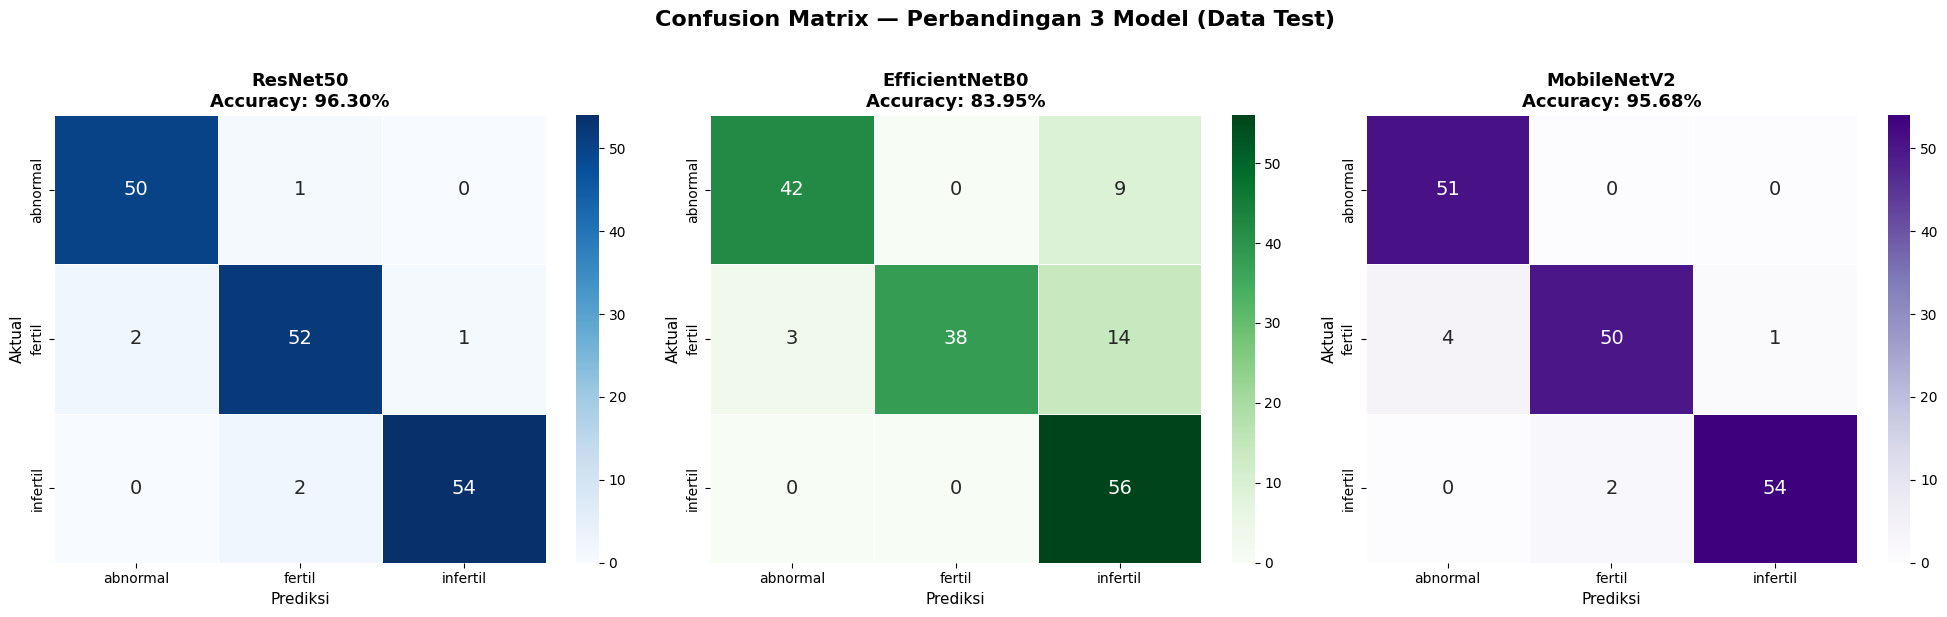

✅ Confusion matrix gabungan test disimpan!


In [ ]:
# ================================================================
# CELL EV3 - CONFUSION MATRIX GABUNGAN TEST ONLY (3 MODEL)
# ================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrix — Perbandingan 3 Model (Data Test)',
             fontsize=16, fontweight='bold', y=1.02)

cmaps = {"ResNet50": "Blues", "EfficientNetB0": "Greens", "MobileNetV2": "Purples"}

for idx, nama in enumerate(["ResNet50", "EfficientNetB0", "MobileNetV2"]):
    y_true = semua_hasil[nama]["Test"]["y_true"]
    y_pred = semua_hasil[nama]["Test"]["y_pred"]
    acc    = semua_hasil[nama]["Test"]["acc"]
    cm     = confusion_matrix(y_true, y_pred)
    ax     = axes[idx]

    sns.heatmap(cm, annot=True, fmt='d', cmap=cmaps[nama],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5, annot_kws={"size": 14})

    ax.set_title(f'{nama}\nAccuracy: {acc*100:.2f}%',
                 fontweight='bold', fontsize=13)
    ax.set_xlabel('Prediksi', fontsize=11)
    ax.set_ylabel('Aktual', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confmat_gabungan_test.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix gabungan test disimpan!")

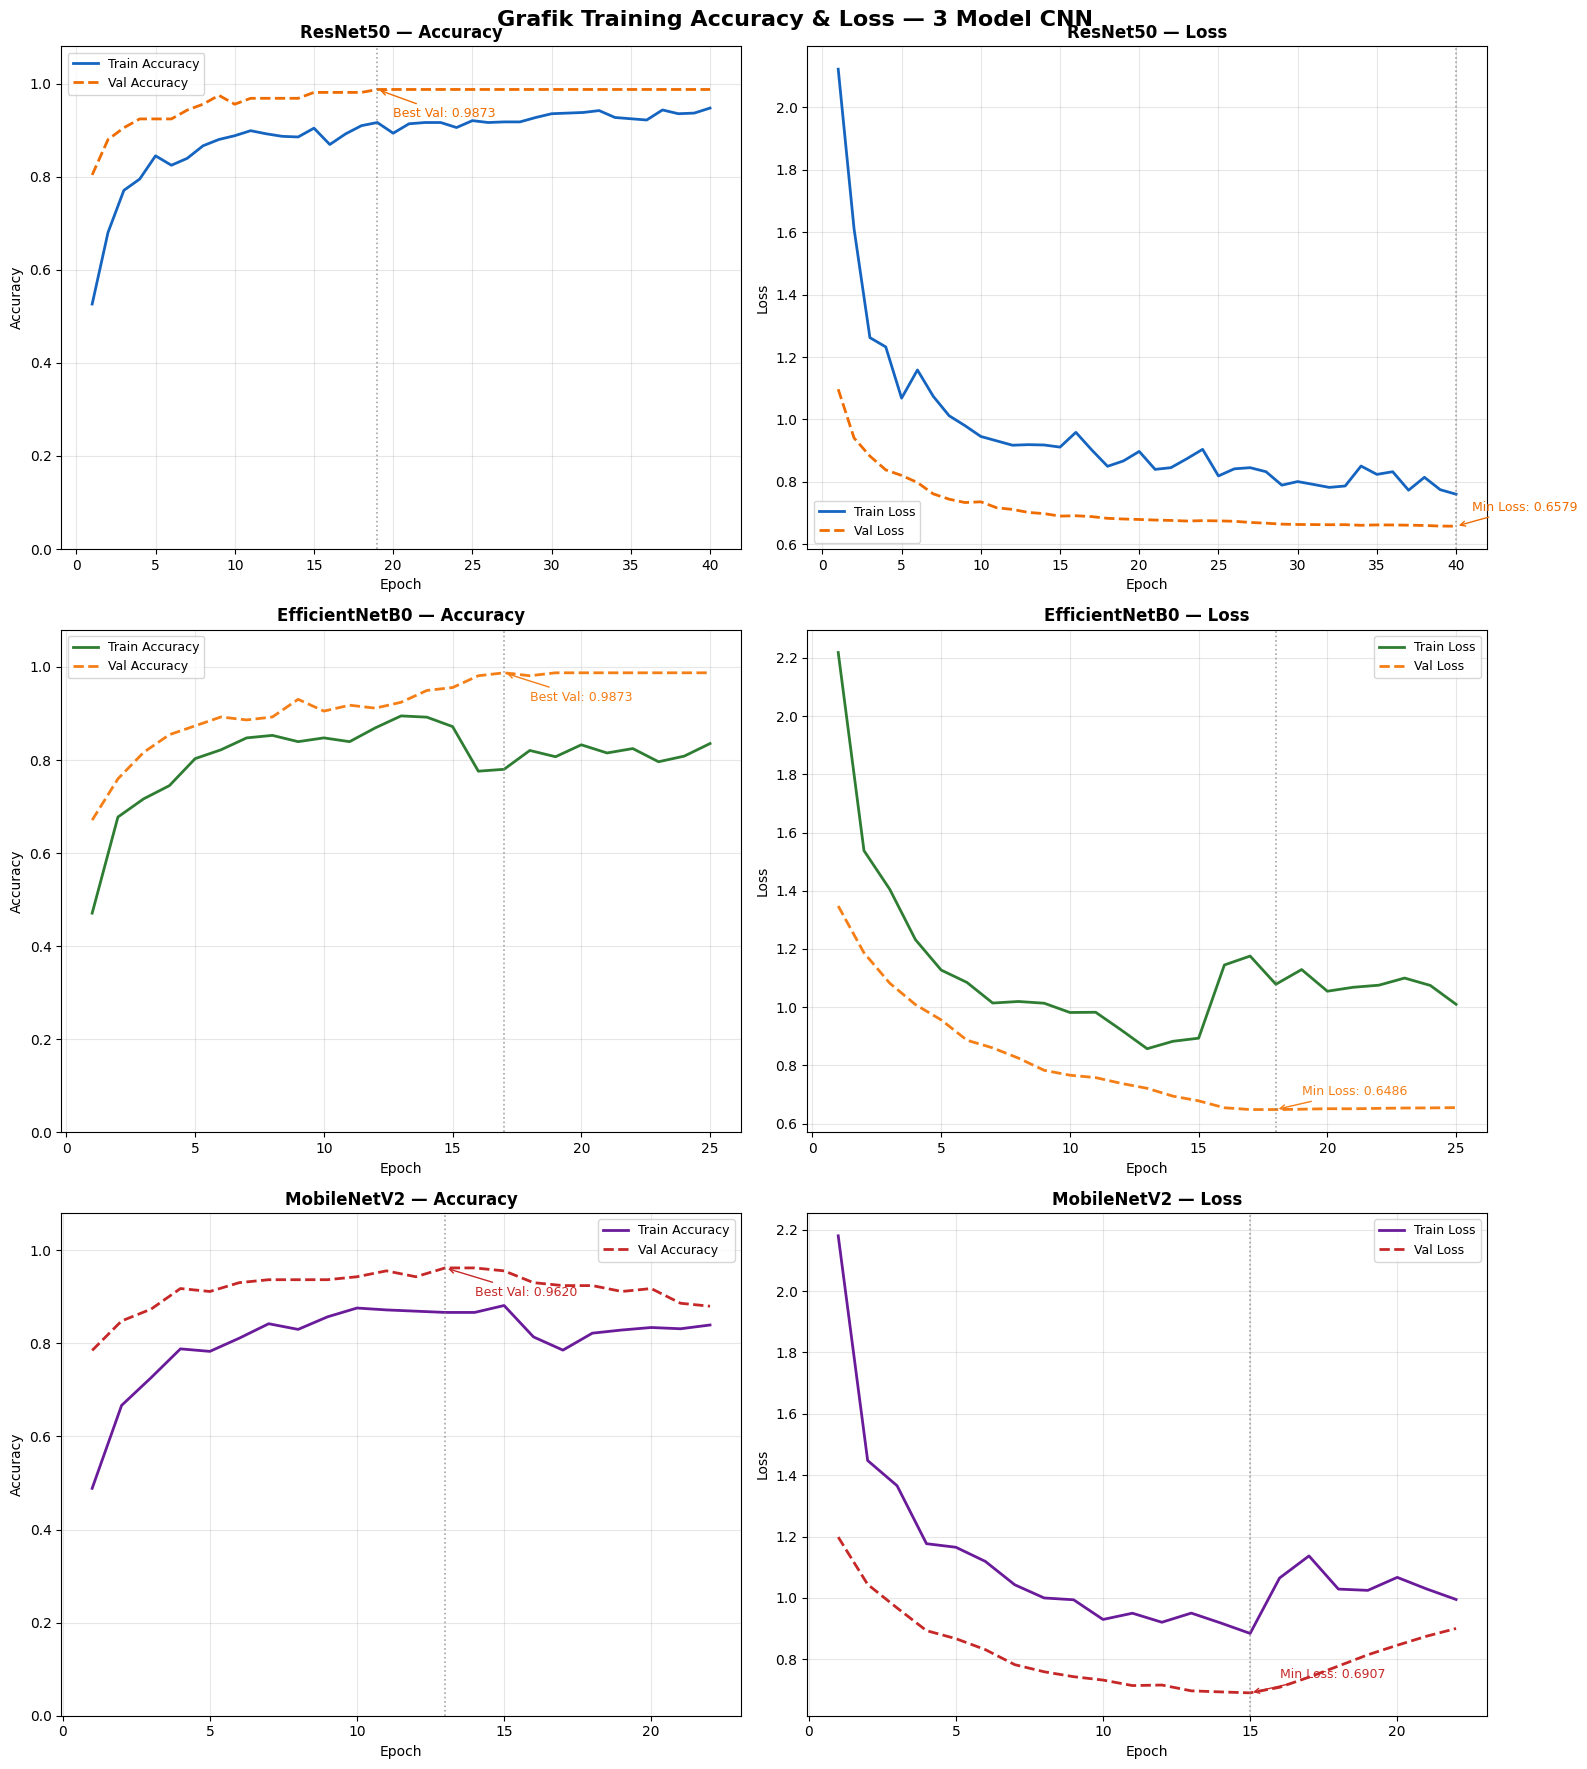

✅ Grafik training disimpan!


In [ ]:
# ================================================================
# CELL EV4 - GRAFIK TRAINING ACCURACY & LOSS
# ================================================================
# Pastikan variabel `hasil` dari Cell 8 training masih tersedia

try:
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    fig.suptitle('Grafik Training Accuracy & Loss — 3 Model CNN',
                 fontsize=16, fontweight='bold')

    colors = {
        "ResNet50"      : ("#1565C0", "#EF6C00"),
        "EfficientNetB0": ("#2E7D32", "#F57F17"),
        "MobileNetV2"   : ("#6A1B9A", "#C62828"),
    }

    for idx, nama in enumerate(["ResNet50", "EfficientNetB0", "MobileNetV2"]):
        hist        = hasil[nama]["history"]
        c_tr, c_vl  = colors[nama]
        ep          = range(1, len(hist['accuracy']) + 1)

        # ── Accuracy ──────────────────────────────────────────────
        ax_acc = axes[idx][0]
        ax_acc.plot(ep, hist['accuracy'],     color=c_tr, lw=2,
                    label='Train Accuracy')
        ax_acc.plot(ep, hist['val_accuracy'], color=c_vl, lw=2,
                    linestyle='--', label='Val Accuracy')
        best_val = max(hist['val_accuracy'])
        best_ep  = hist['val_accuracy'].index(best_val) + 1
        ax_acc.axvline(x=best_ep, color='gray', lw=1.2,
                       linestyle=':', alpha=0.7)
        ax_acc.annotate(f'Best Val: {best_val:.4f}',
                        xy=(best_ep, best_val),
                        xytext=(best_ep + 1, best_val - 0.06),
                        fontsize=9, color=c_vl,
                        arrowprops=dict(arrowstyle='->', color=c_vl))
        ax_acc.set_title(f'{nama} — Accuracy', fontweight='bold', fontsize=12)
        ax_acc.set_xlabel('Epoch')
        ax_acc.set_ylabel('Accuracy')
        ax_acc.legend(fontsize=9)
        ax_acc.grid(alpha=0.3)
        ax_acc.set_ylim([0, 1.08])

        # ── Loss ──────────────────────────────────────────────────
        ax_loss = axes[idx][1]
        ax_loss.plot(ep, hist['loss'],     color=c_tr, lw=2,
                     label='Train Loss')
        ax_loss.plot(ep, hist['val_loss'], color=c_vl, lw=2,
                     linestyle='--', label='Val Loss')
        min_loss = min(hist['val_loss'])
        min_ep   = hist['val_loss'].index(min_loss) + 1
        ax_loss.axvline(x=min_ep, color='gray', lw=1.2,
                        linestyle=':', alpha=0.7)
        ax_loss.annotate(f'Min Loss: {min_loss:.4f}',
                         xy=(min_ep, min_loss),
                         xytext=(min_ep + 1, min_loss + 0.05),
                         fontsize=9, color=c_vl,
                         arrowprops=dict(arrowstyle='->', color=c_vl))
        ax_loss.set_title(f'{nama} — Loss', fontweight='bold', fontsize=12)
        ax_loss.set_xlabel('Epoch')
        ax_loss.set_ylabel('Loss')
        ax_loss.legend(fontsize=9)
        ax_loss.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'grafik_training.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Grafik training disimpan!")

except NameError:
    print("⚠️  Variabel 'hasil' tidak ditemukan.")
    print("   Grafik hanya bisa dibuat di sesi yang sama dengan training.")



        TABEL PERBANDINGAN AKURASI 3 MODEL (DATA TEST)
  Model                Accuracy  Precision     Recall   F1-Score
  --------------------------------------------------------------------
  ResNet50               0.9630     0.9631     0.9630     0.9630  ⭐ TERBAIK
  EfficientNetB0         0.8395     0.8784     0.8395     0.8397
  MobileNetV2            0.9568     0.9578     0.9568     0.9566



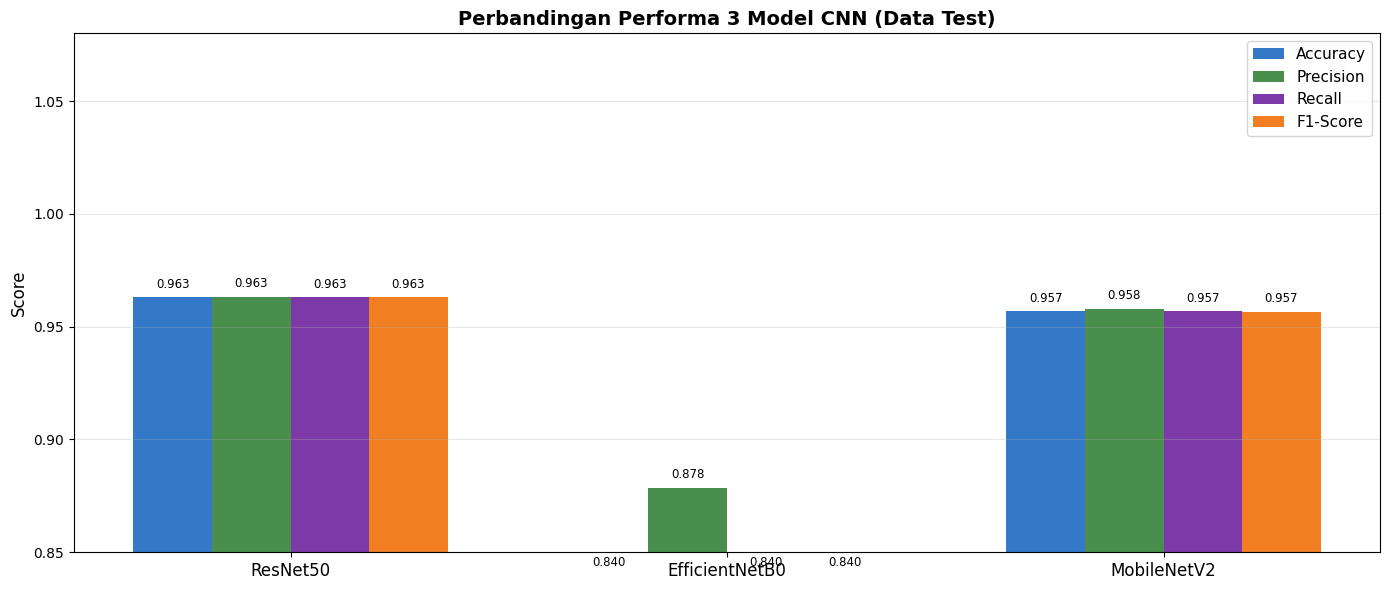

✅ Tabel perbandingan disimpan!


In [ ]:
# ================================================================
# CELL EV5 - TABEL PERBANDINGAN AKURASI 3 MODEL
# ================================================================

print("\n" + "="*72)
print("        TABEL PERBANDINGAN AKURASI 3 MODEL (DATA TEST)")
print("="*72)
print(f"  {'Model':<18} {'Accuracy':>10} {'Precision':>10} "
      f"{'Recall':>10} {'F1-Score':>10}")
print(f"  {'-'*68}")

model_terbaik = max(semua_hasil,
                    key=lambda x: semua_hasil[x]['Test']['acc'])
tabel_data    = {}

for nama in ["ResNet50", "EfficientNetB0", "MobileNetV2"]:
    m   = semua_hasil[nama]["Test"]
    tabel_data[nama] = m
    tag = "  ⭐ TERBAIK" if nama == model_terbaik else ""
    print(f"  {nama:<18} {m['acc']:>10.4f} {m['prec']:>10.4f} "
          f"{m['rec']:>10.4f} {m['f1']:>10.4f}{tag}")

print(f"  {'='*68}\n")

# ── Bar chart 4 metrik ────────────────────────────────────────────
labels     = ["ResNet50", "EfficientNetB0", "MobileNetV2"]
metrics    = ["acc",       "prec",       "rec",     "f1"]
m_labels   = ["Accuracy", "Precision", "Recall", "F1-Score"]
bar_colors = ["#1565C0",  "#2E7D32",   "#6A1B9A", "#EF6C00"]

x   = np.arange(len(labels))
w   = 0.18
fig, ax = plt.subplots(figsize=(14, 6))

for i, (met, col, lab) in enumerate(zip(metrics, bar_colors, m_labels)):
    vals = [tabel_data[m][met] for m in labels]
    bars = ax.bar(x + i*w, vals, w, label=lab, color=col, alpha=0.87)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8.5)

ax.set_title('Perbandingan Performa 3 Model CNN (Data Test)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + w*1.5)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim([0.85, 1.08])
ax.set_ylabel('Score', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'tabel_perbandingan.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Tabel perbandingan disimpan!")

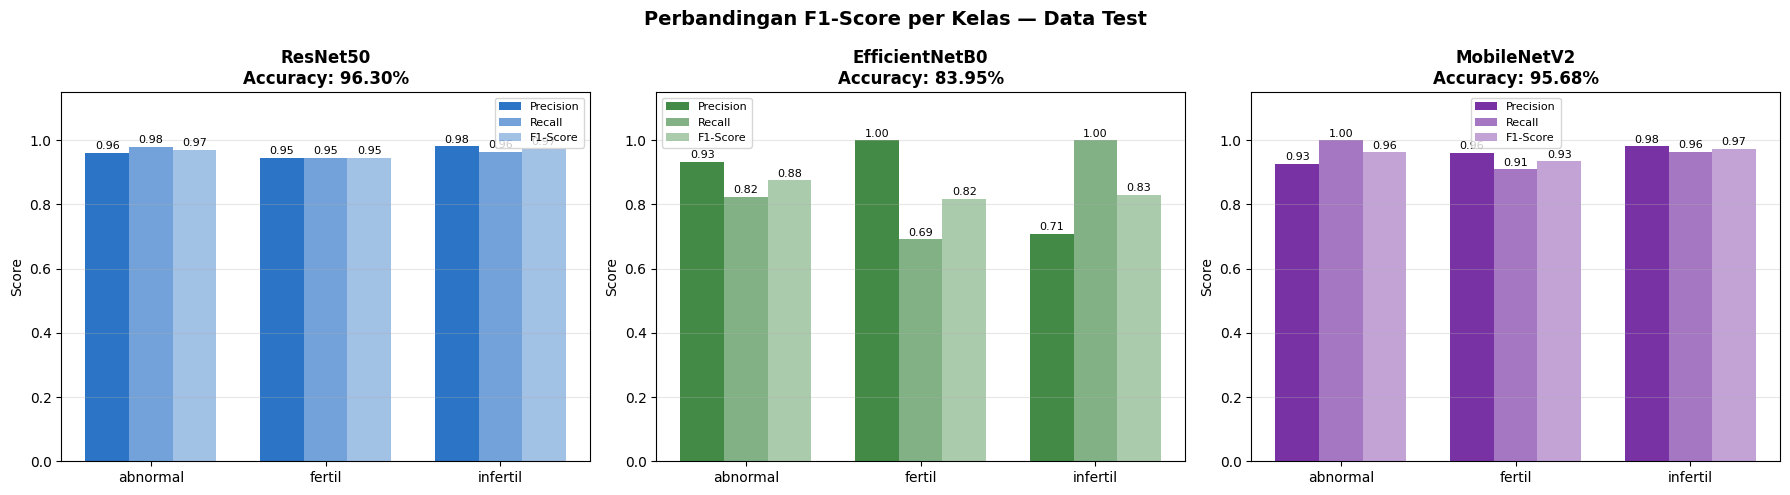

✅ Perbandingan per kelas disimpan!


In [ ]:
# ================================================================
# CELL EV6 - PERBANDINGAN AKURASI PER KELAS (F1-SCORE)
# ================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Perbandingan F1-Score per Kelas — Data Test',
             fontsize=14, fontweight='bold')

model_colors = {
    "ResNet50"      : "#1565C0",
    "EfficientNetB0": "#2E7D32",
    "MobileNetV2"   : "#6A1B9A",
}

for idx, nama in enumerate(["ResNet50", "EfficientNetB0", "MobileNetV2"]):
    y_true  = semua_hasil[nama]["Test"]["y_true"]
    y_pred  = semua_hasil[nama]["Test"]["y_pred"]
    report  = classification_report(y_true, y_pred,
                                    target_names=CLASS_NAMES,
                                    output_dict=True, zero_division=0)
    f1_vals = [report[k]['f1-score'] for k in CLASS_NAMES]
    pr_vals = [report[k]['precision'] for k in CLASS_NAMES]
    rc_vals = [report[k]['recall']    for k in CLASS_NAMES]

    ax  = axes[idx]
    x   = np.arange(len(CLASS_NAMES))
    w   = 0.25

    b1 = ax.bar(x - w,  pr_vals, w, label='Precision',
                color=model_colors[nama], alpha=0.9)
    b2 = ax.bar(x,      rc_vals, w, label='Recall',
                color=model_colors[nama], alpha=0.6)
    b3 = ax.bar(x + w,  f1_vals, w, label='F1-Score',
                color=model_colors[nama], alpha=0.4)

    for bars in [b1, b2, b3]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=8)

    acc_test = semua_hasil[nama]["Test"]["acc"]
    ax.set_title(f'{nama}\nAccuracy: {acc_test*100:.2f}%',
                 fontweight='bold', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, fontsize=10)
    ax.set_ylim([0, 1.15])
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'perbandingan_per_kelas.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Perbandingan per kelas disimpan!")


In [ ]:
# ================================================================
# CELL EV7 - ANALISIS MODEL TERBAIK
# ================================================================

print("\n" + "="*65)
print("  ANALISIS MODEL TERBAIK")
print("="*65)

ranking = sorted(semua_hasil.items(),
                 key=lambda x: x[1]['Test']['acc'], reverse=True)
medals  = ["🥇", "🥈", "🥉"]

print("\n📊 Ranking Model:\n")
for rank, (nama, data) in enumerate(ranking):
    m = data["Test"]
    print(f"  {medals[rank]} Peringkat {rank+1}: {nama}")
    print(f"     Accuracy  : {m['acc']*100:.2f}%")
    print(f"     Precision : {m['prec']:.4f}")
    print(f"     Recall    : {m['rec']:.4f}")
    print(f"     F1-Score  : {m['f1']:.4f}\n")

# Detail per kelas model terbaik
terbaik_data = semua_hasil[model_terbaik]["Test"]
report_best  = classification_report(
    terbaik_data["y_true"], terbaik_data["y_pred"],
    target_names=CLASS_NAMES, output_dict=True, zero_division=0
)

print(f"{'='*65}")
print(f"  DETAIL {model_terbaik} PER KELAS")
print(f"{'='*65}\n")
for kelas in CLASS_NAMES:
    r = report_best[kelas]
    print(f"  [{kelas.upper()}]")
    print(f"    Precision : {r['precision']:.4f}")
    print(f"    Recall    : {r['recall']:.4f}")
    print(f"    F1-Score  : {r['f1-score']:.4f}")
    print(f"    Support   : {int(r['support'])} gambar\n")

# Selisih antar model
selisih_12 = (ranking[0][1]['Test']['acc'] -
              ranking[1][1]['Test']['acc']) * 100
selisih_13 = (ranking[0][1]['Test']['acc'] -
              ranking[2][1]['Test']['acc']) * 100

print(f"{'='*65}")
print(f"  KESIMPULAN")
print(f"{'='*65}")
print(f"""
  Model terbaik untuk klasifikasi fertilitas telur ayam
  berdasarkan citra candling adalah {model_terbaik}
  dengan akurasi {terbaik_data['acc']*100:.2f}%.

  Unggul {selisih_12:.2f}% dari {ranking[1][0]}
  dan {selisih_13:.2f}% dari {ranking[2][0]}.

  F1-Score  : {terbaik_data['f1']:.4f}
  Precision : {terbaik_data['prec']:.4f}
  Recall    : {terbaik_data['rec']:.4f}
""")



  ANALISIS MODEL TERBAIK

📊 Ranking Model:

  🥇 Peringkat 1: ResNet50
     Accuracy  : 96.30%
     Precision : 0.9631
     Recall    : 0.9630
     F1-Score  : 0.9630

  🥈 Peringkat 2: MobileNetV2
     Accuracy  : 95.68%
     Precision : 0.9578
     Recall    : 0.9568
     F1-Score  : 0.9566

  🥉 Peringkat 3: EfficientNetB0
     Accuracy  : 83.95%
     Precision : 0.8784
     Recall    : 0.8395
     F1-Score  : 0.8397

  DETAIL ResNet50 PER KELAS

  [ABNORMAL]
    Precision : 0.9615
    Recall    : 0.9804
    F1-Score  : 0.9709
    Support   : 51 gambar

  [FERTIL]
    Precision : 0.9455
    Recall    : 0.9455
    F1-Score  : 0.9455
    Support   : 55 gambar

  [INFERTIL]
    Precision : 0.9818
    Recall    : 0.9643
    F1-Score  : 0.9730
    Support   : 56 gambar

  KESIMPULAN

  Model terbaik untuk klasifikasi fertilitas telur ayam
  berdasarkan citra candling adalah ResNet50
  dengan akurasi 96.30%.

  Unggul 0.62% dari MobileNetV2
  dan 12.35% dari EfficientNetB0.

  F1-Score  : 0

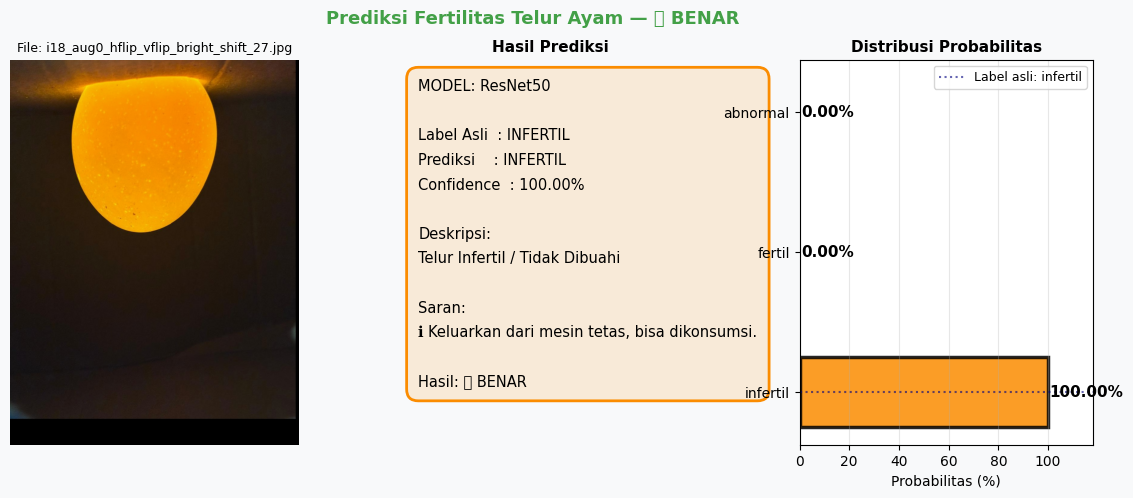


  HASIL PREDIKSI
  File       : i18_aug0_hflip_vflip_bright_shift_27.jpg
  Model      : ResNet50
  Label Asli : INFERTIL
  Prediksi   : INFERTIL
  Confidence : 100.00%
  Hasil      : ✅ BENAR


In [ ]:
# ================================================================
# CELL EV9 - PREDIKSI GAMBAR RANDOM (1 GAMBAR)
# Jalankan berulang untuk gambar berbeda
# ================================================================

import random
from PIL import Image

WARNA_KELAS = {
    "abnormal": "#E53935",
    "fertil"  : "#43A047",
    "infertil": "#FB8C00",
}
DESKRIPSI_KELAS = {
    "abnormal": "Telur Mati / Tidak Berkembang",
    "fertil"  : "Telur Fertil / Berkembang Normal",
    "infertil": "Telur Infertil / Tidak Dibuahi",
}
SARAN_KELAS = {
    "abnormal": "⚠️ Segera keluarkan dari mesin tetas!",
    "fertil"  : "✅ Lanjutkan inkubasi, pantau suhu & kelembaban.",
    "infertil": "ℹ️ Keluarkan dari mesin tetas, bisa dikonsumsi.",
}

# Pilih model terbaik otomatis
AKURASI_MODEL = {
    "ResNet50"      : semua_hasil["ResNet50"]["Test"]["acc"],
    "EfficientNetB0": semua_hasil["EfficientNetB0"]["Test"]["acc"],
    "MobileNetV2"   : semua_hasil["MobileNetV2"]["Test"]["acc"],
}
nama_terbaik  = max(AKURASI_MODEL, key=AKURASI_MODEL.get)
model_pred    = loaded_models[nama_terbaik]
preprocess_fn = PREPROCESS_MAP[nama_terbaik]

def ambil_random(test_dir, class_names):
    kelas = random.choice(class_names)
    folder = os.path.join(test_dir, kelas)
    files_list = [f for f in os.listdir(folder)
                  if f.lower().endswith((".jpg",".jpeg",".png"))]
    fname = random.choice(files_list)
    return os.path.join(folder, fname), kelas, fname

def prediksi_img(img_path):
    img     = Image.open(img_path).convert("RGB")
    arr     = np.array(img.resize((IMG_SIZE, IMG_SIZE)), dtype=np.float32)
    proc    = preprocess_fn(np.expand_dims(arr, axis=0))
    probs   = model_pred.predict(proc, verbose=0)[0]
    idx     = np.argmax(probs)
    return CLASS_NAMES[idx], probs[idx]*100, probs, img

def tampilkan_prediksi(img_pil, kelas_asli, kelas_pred,
                       conf, probs, nama_file):
    benar      = kelas_asli == kelas_pred
    warna_box  = WARNA_KELAS[kelas_pred]
    warna_stat = "#43A047" if benar else "#E53935"
    status_txt = "✅ BENAR" if benar else "❌ SALAH"

    fig = plt.figure(figsize=(14, 5))
    fig.patch.set_facecolor('#F8F9FA')
    gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

    # ── Gambar ────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0])
    ax1.imshow(img_pil)
    ax1.axis('off')
    ax1.set_title(f'File: {nama_file}', fontsize=9, pad=6)
    for spine in ax1.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(warna_stat)
        spine.set_linewidth(5)

    # ── Info prediksi ─────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1])
    ax2.axis('off')
    info = (
        f"MODEL: {nama_terbaik}\n\n"
        f"Label Asli  : {kelas_asli.upper()}\n"
        f"Prediksi    : {kelas_pred.upper()}\n"
        f"Confidence  : {conf:.2f}%\n\n"
        f"Deskripsi:\n{DESKRIPSI_KELAS[kelas_pred]}\n\n"
        f"Saran:\n{SARAN_KELAS[kelas_pred]}\n\n"
        f"Hasil: {status_txt}"
    )
    ax2.text(0.05, 0.95, info,
             transform=ax2.transAxes, va='top', ha='left',
             fontsize=10.5, linespacing=1.8,
             bbox=dict(boxstyle='round,pad=0.8',
                       facecolor=warna_box+'22',
                       edgecolor=warna_box, linewidth=2))
    ax2.set_title('Hasil Prediksi', fontsize=11, fontweight='bold')

    # ── Bar chart probabilitas ────────────────────────────────────
    ax3 = fig.add_subplot(gs[2])
    bar_colors = [WARNA_KELAS[c] for c in CLASS_NAMES]
    bars = ax3.barh(CLASS_NAMES, probs * 100,
                    color=bar_colors, alpha=0.85, height=0.5)

    for bar, prob in zip(bars, probs):
        w = bar.get_width()
        ax3.text(w + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{prob*100:.2f}%', va='center', ha='left',
                 fontsize=11, fontweight='bold')

    idx_pred = CLASS_NAMES.index(kelas_pred)
    bars[idx_pred].set_edgecolor('black')
    bars[idx_pred].set_linewidth(2.5)

    idx_asli = CLASS_NAMES.index(kelas_asli)
    ax3.axhline(y=idx_asli, color='navy', lw=1.5,
                linestyle=':', alpha=0.6,
                label=f'Label asli: {kelas_asli}')
    ax3.legend(fontsize=9)
    ax3.set_xlim([0, 118])
    ax3.set_xlabel('Probabilitas (%)', fontsize=10)
    ax3.set_title('Distribusi Probabilitas', fontsize=11, fontweight='bold')
    ax3.grid(axis='x', alpha=0.3)
    ax3.invert_yaxis()

    plt.suptitle(
        f'Prediksi Fertilitas Telur Ayam — {status_txt}',
        fontsize=13, fontweight='bold', color=warna_stat
    )
    plt.savefig('/content/hasil_prediksi.png',
                dpi=150, bbox_inches='tight', facecolor='#F8F9FA')
    plt.show()

# ── Jalankan prediksi 1 gambar random ────────────────────────────
img_path, kelas_asli, nama_file = ambil_random(TEST_DIR, CLASS_NAMES)
kelas_pred, conf, probs, img_pil = prediksi_img(img_path)
tampilkan_prediksi(img_pil, kelas_asli, kelas_pred,
                   conf, probs, nama_file)

print(f"\n  {'='*50}")
print(f"  HASIL PREDIKSI")
print(f"  {'='*50}")
print(f"  File       : {nama_file}")
print(f"  Model      : {nama_terbaik}")
print(f"  Label Asli : {kelas_asli.upper()}")
print(f"  Prediksi   : {kelas_pred.upper()}")
print(f"  Confidence : {conf:.2f}%")
print(f"  Hasil      : {'✅ BENAR' if kelas_asli==kelas_pred else '❌ SALAH'}")
print(f"  {'='*50}")


🎲 Prediksi 9 gambar random...



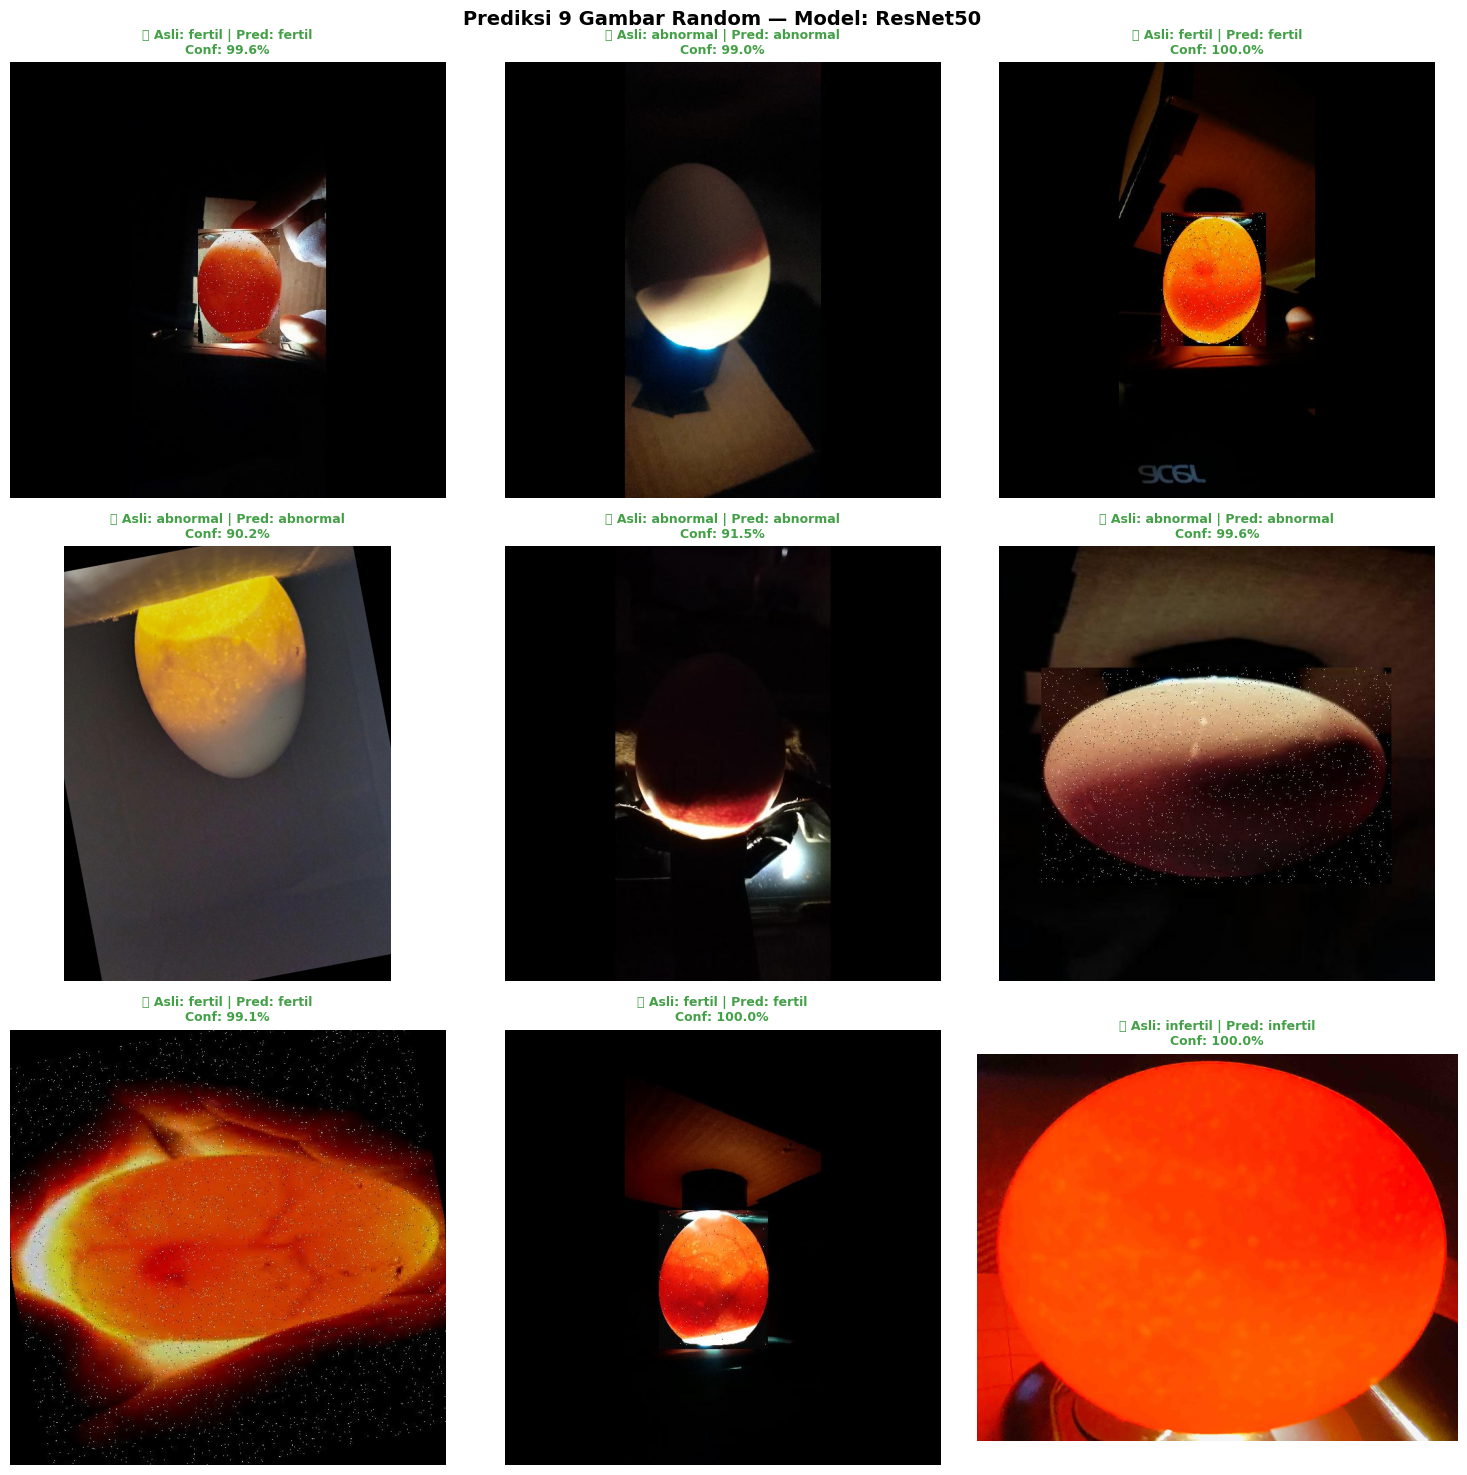


  RINGKASAN 9 PREDIKSI RANDOM
  No   File                   Asli         Prediksi        Conf  Hasil
  -----------------------------------------------------------------
  1    20220630_214922_jpg.rf.8f80adefde9d0bf79265bfd418ace4fd.jpg fertil       fertil         99.6%  ✅ Benar
  2    20220710_210340_jpg.rf.50d6cddd630603ab6b57084fcb4b5403.jpg abnormal     abnormal       99.0%  ✅ Benar
  3    20220626_180939_jpg.rf.c274c9e14ade5b2914494c8d9359b073.jpg fertil       fertil        100.0%  ✅ Benar
  4    d23_aug2_hflip_vflip_rot10_bright_67.jpg abnormal     abnormal       90.2%  ✅ Benar
  5    IMG_20220801_210600_jpg.rf.41a73fae885f3fbd376ac1b2156798d6.jpg abnormal     abnormal       91.5%  ✅ Benar
  6    h8-4-muerto-dia12_jpg.rf.0eef73bf66e9476d032be3250ac56a90.jpg abnormal     abnormal       99.6%  ✅ Benar
  7    download-3-_jpg.rf.afc531fb8488e65e554da937190c8f1f_aug2_vflip_rot10_bright_60.jpg fertil       fertil         99.1%  ✅ Benar
  8    20220701_193731_jpg.rf.8f61f0c0de6792937fa0

In [ ]:
# ================================================================
# CELL EV10 - PREDIKSI GRID 9 GAMBAR RANDOM
# Ubah N_GAMBAR sesuai kebutuhan (kelipatan 3)
# ================================================================

N_GAMBAR = 9   # ← bisa diganti 6, 12, 15

print(f"🎲 Prediksi {N_GAMBAR} gambar random...\n")

cols      = 3
rows      = N_GAMBAR // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))
fig.suptitle(
    f'Prediksi {N_GAMBAR} Gambar Random — Model: {nama_terbaik}',
    fontsize=14, fontweight='bold'
)

benar_count = 0
hasil_list  = []

for i, ax in enumerate(axes.flat):
    img_path, kelas_asli, nama_file = ambil_random(TEST_DIR, CLASS_NAMES)
    kelas_pred, conf, probs, img_pil = prediksi_img(img_path)

    benar = kelas_asli == kelas_pred
    if benar: benar_count += 1

    hasil_list.append({
        "No"        : i + 1,
        "File"      : nama_file,
        "Asli"      : kelas_asli,
        "Prediksi"  : kelas_pred,
        "Confidence": f"{conf:.1f}%",
        "Hasil"     : "✅ Benar" if benar else "❌ Salah"
    })

    warna_border = "#43A047" if benar else "#E53935"
    status       = "✅" if benar else "❌"

    ax.imshow(img_pil)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(warna_border)
        spine.set_linewidth(4)
    ax.set_title(
        f"{status} Asli: {kelas_asli} | Pred: {kelas_pred}\n"
        f"Conf: {conf:.1f}%",
        fontsize=9, color=warna_border, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('/content/prediksi_grid.png', dpi=150, bbox_inches='tight')
plt.show()

# Ringkasan tabel
print(f"\n{'='*70}")
print(f"  RINGKASAN {N_GAMBAR} PREDIKSI RANDOM")
print(f"{'='*70}")
print(f"  {'No':<4} {'File':<22} {'Asli':<12} "
      f"{'Prediksi':<12} {'Conf':>7}  {'Hasil'}")
print(f"  {'-'*65}")
for h in hasil_list:
    print(f"  {h['No']:<4} {h['File']:<22} {h['Asli']:<12} "
          f"{h['Prediksi']:<12} {h['Confidence']:>7}  {h['Hasil']}")
print(f"  {'='*65}")
print(f"  Benar  : {benar_count}/{N_GAMBAR}")
print(f"  Salah  : {N_GAMBAR-benar_count}/{N_GAMBAR}")
print(f"  Akurasi: {benar_count/N_GAMBAR*100:.1f}%")

print(f"\n📁 Semua file disimpan di: {SAVE_DIR}")
print("   ✅ confmat_gabungan_test.png")
print("   ✅ grafik_training.png")
print("   ✅ tabel_perbandingan.png")
print("   ✅ perbandingan_per_kelas.png")
print("   ✅ /content/hasil_prediksi.png")
print("   ✅ /content/prediksi_grid.png")


In [ ]:
# ================================================================
# CELL EV8 - DOWNLOAD MODEL H5
# ================================================================

from google.colab import files

print("📦 Cek ketersediaan model...\n")
for nama in ["ResNet50", "EfficientNetB0", "MobileNetV2"]:
    path = os.path.join(SAVE_DIR, f"best_{nama}.h5")
    if os.path.exists(path):
        ukuran = os.path.getsize(path) / (1024 * 1024)
        print(f"  ✅ best_{nama}.h5 ({ukuran:.1f} MB)")
    else:
        print(f"  ❌ best_{nama}.h5 tidak ditemukan!")

print("\n⬇️  Memulai download...\n")
for nama in ["ResNet50", "EfficientNetB0", "MobileNetV2"]:
    path = os.path.join(SAVE_DIR, f"best_{nama}.h5")
    if os.path.exists(path):
        print(f"  ⬇️  Downloading best_{nama}.h5 ...")
        files.download(path)
        print(f"  ✅ Selesai!\n")

print("🎉 Semua model berhasil didownload!")

📦 Cek ketersediaan model...

  ✅ best_ResNet50.h5 (130.9 MB)
  ✅ best_EfficientNetB0.h5 (30.4 MB)
  ✅ best_MobileNetV2.h5 (13.2 MB)

⬇️  Memulai download...

  ⬇️  Downloading best_ResNet50.h5 ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ Selesai!

  ⬇️  Downloading best_EfficientNetB0.h5 ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ Selesai!

  ⬇️  Downloading best_MobileNetV2.h5 ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ Selesai!

🎉 Semua model berhasil didownload!
